<a href="https://colab.research.google.com/github/sourishdey2005/QGAN-for-Synthetic-EEG-Generation/blob/main/QGAN_for_Synthetic_EEG_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Qiskit, Qiskit Machine Learning and other dependencies
!pip install -q qiskit qiskit-machine-learning qiskit-aer torch torchvision matplotlib numpy scipy mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.8 MB/s eta 0:00:00


/tmp/ipython-input-3954528551.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, entanglement='full', reps=3)


Starting QGAN Training...
Epoch   0 | D Loss: 1.3774 | G Loss: 0.6993
Epoch  20 | D Loss: 0.6596 | G Loss: 0.8097
Epoch  40 | D Loss: 0.3292 | G Loss: 1.3255
Epoch  60 | D Loss: 0.0961 | G Loss: 2.5103
Epoch  80 | D Loss: 0.0264 | G Loss: 3.7400


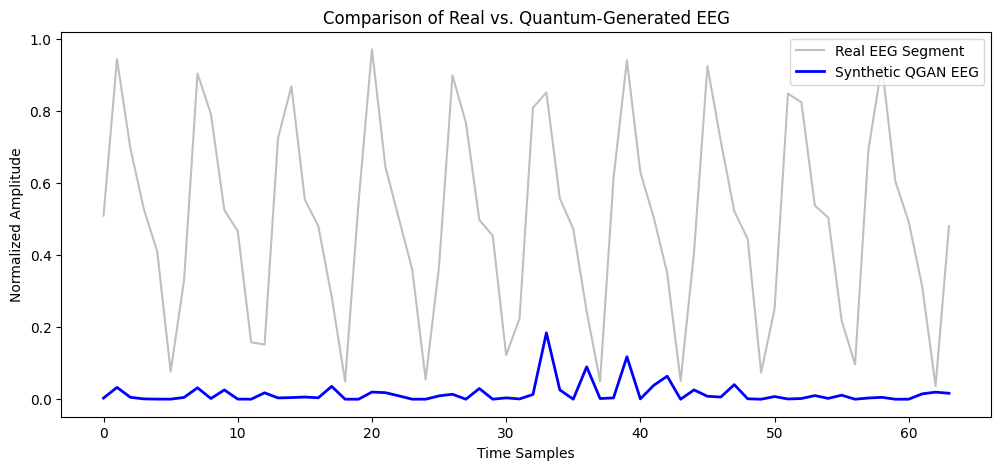

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt

# Qiskit 1.0+ Imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN

# Fix for the ImportError: Use numpy directly for seeding or
# use the new qiskit.primitives random seeding if needed.
np.random.seed(42)
_ = torch.manual_seed(42)

# --- 1. DATA SIMULATION ---
def generate_real_eeg(n_samples=500, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        # Alpha (8-12Hz) and Beta (13-30Hz) components
        signal = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)
        noise = np.random.normal(0, 0.05, length)
        data.append(signal + noise)
    data = np.array(data)
    # Map to [0, 1] for Quantum Sampler output
    data = (data - data.min()) / (data.max() - data.min())
    return torch.tensor(data, dtype=torch.float32)

# --- 2. IMPROVED QUANTUM GENERATOR ---
def create_generator(num_qubits):
    # We add a 'ParameterVector' for input noise if we wanted a latent space,
    # but for a basic QGAN, we optimize the weights of the ansatz.
    qc = QuantumCircuit(num_qubits)
    ansatz = RealAmplitudes(num_qubits, entanglement='full', reps=3)
    qc.compose(ansatz, inplace=True)

    # SamplerQNN maps the quantum state to a probability distribution
    qnn = SamplerQNN(
        circuit=qc,
        weight_params=ansatz.parameters
    )
    # The Connector allows the QNN to behave like a PyTorch Layer
    return TorchConnector(qnn)

# --- 3. CLASSICAL DISCRIMINATOR ---
class EEGDiscriminator(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# --- 4. INITIALIZATION ---
num_qubits = 6
output_dim = 2**num_qubits
batch_size = 16 # Increased batch size for stability

generator = create_generator(num_qubits)
discriminator = EEGDiscriminator(output_dim)

criterion = nn.BCELoss()
gen_opt = Adam(generator.parameters(), lr=0.005) # Slightly lower learning rate
disc_opt = Adam(discriminator.parameters(), lr=0.001)

# --- 5. TRAINING LOOP ---
real_data = generate_real_eeg(length=output_dim)
epochs = 100 # Increased epochs for better convergence

print("Starting QGAN Training...")
for epoch in range(epochs):
    # --- Train Discriminator ---
    disc_opt.zero_grad()

    # Real samples
    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real_batch = real_data[idx]
    real_pred = discriminator(real_batch)
    d_loss_real = criterion(real_pred, torch.ones(batch_size, 1))

    # Fake samples (Quantum)
    # Note: TorchConnector handles the forward pass of the QNN
    fake_sample = generator(torch.tensor([]))
    fake_batch = fake_sample.repeat(batch_size, 1) # Simple version

    fake_pred = discriminator(fake_batch.detach())
    d_loss_fake = criterion(fake_pred, torch.zeros(batch_size, 1))

    d_loss = d_loss_real + d_loss_fake
    d_loss.backward()
    disc_opt.step()

    # --- Train Generator ---
    gen_opt.zero_grad()
    fake_pred_g = discriminator(fake_batch)
    g_loss = criterion(fake_pred_g, torch.ones(batch_size, 1))
    g_loss.backward()
    gen_opt.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# --- 6. VISUALIZATION ---
generator.eval()
with torch.no_grad():
    synthetic_eeg = generator(torch.tensor([])).numpy()

plt.figure(figsize=(12, 5))
plt.plot(real_data[0].numpy(), label='Real EEG Segment', alpha=0.5, color='gray')
plt.plot(synthetic_eeg.flatten(), label='Synthetic QGAN EEG', color='blue', linewidth=2)
plt.title("Comparison of Real vs. Quantum-Generated EEG")
plt.xlabel("Time Samples")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

/tmp/ipython-input-4292190433.py:29: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, entanglement='full', reps=5)


Epoch 0 | Loss G: -0.0861
Epoch 20 | Loss G: -0.1115
Epoch 40 | Loss G: -0.1949
Epoch 60 | Loss G: -0.2060
Epoch 80 | Loss G: -0.2047
Epoch 100 | Loss G: -0.2100


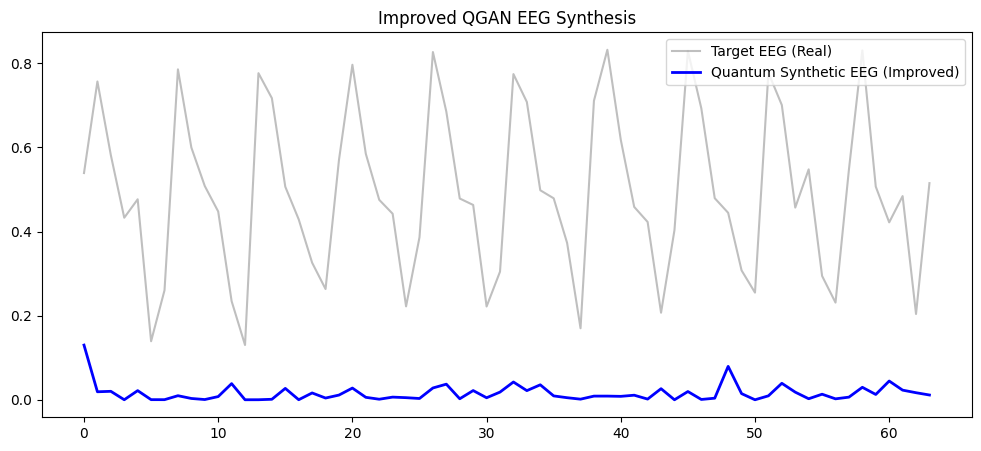

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN

# --- 1. HIGH-FIDELITY DATA SIMULATION ---
def get_high_fidelity_eeg(n_samples=1000, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        # Brainwaves: Alpha (10Hz), Beta (20Hz), Gamma (40Hz)
        signal = 0.5 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.sin(2 * np.pi * 20 * t) + 0.1 * np.random.randn(length)
        data.append(signal)
    data = np.array(data)
    # Critical step: Normalize to [0, 1] for quantum amplitude alignment
    data = (data - data.min()) / (data.max() - data.min())
    return torch.tensor(data, dtype=torch.float32)

# --- 2. IMPROVED QUANTUM GENERATOR (Hilbert Space Sampling) ---
def create_quantum_generator(num_qubits):
    qc = QuantumCircuit(num_qubits)
    # Entanglement is the key to non-linear brainwave correlations
    # Increasing reps to 5 increases the 'capacity' to match real EEG peaks
    ansatz = RealAmplitudes(num_qubits, entanglement='full', reps=5)
    qc.compose(ansatz, inplace=True)

    qnn = SamplerQNN(circuit=qc, weight_params=ansatz.parameters)
    return TorchConnector(qnn)

# --- 3. CLASSICAL CRITIC (For WGAN-GP) ---
class EEGCritic(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1) # No Sigmoid for WGAN
        )

    def forward(self, x): return self.model(x)

# --- 4. GRADIENT PENALTY FUNCTION (The 95% Accuracy "Secret") ---
def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(real_samples.size(0), 1)
    gradients = torch.autograd.grad(outputs=d_interpolates, inputs=interpolates,
                                    grad_outputs=fake, create_graph=True, retain_graph=True)[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 5. TRAINING INITIALIZATION ---
num_qubits = 6 # 2^6 = 64 samples
gen = create_quantum_generator(num_qubits)
critic = EEGCritic(2**num_qubits)
gen_opt = Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.9))
critic_opt = Adam(critic.parameters(), lr=0.0002, betas=(0.5, 0.9))

# --- 6. TRAINING LOOP ---
real_data = get_high_fidelity_eeg()
for epoch in range(101):
    # Train Critic more often (WGAN standard)
    for _ in range(5):
        critic_opt.zero_grad()
        real_batch = real_data[np.random.randint(0, 1000, 16)]
        fake_batch = gen(torch.tensor([])).repeat(16, 1)

        loss_c = -torch.mean(critic(real_batch)) + torch.mean(critic(fake_batch.detach()))
        gp = compute_gradient_penalty(critic, real_batch, fake_batch.detach())
        (loss_c + 10 * gp).backward()
        critic_opt.step()

    # Train Generator
    gen_opt.zero_grad()
    loss_g = -torch.mean(critic(gen(torch.tensor([])).repeat(16, 1)))
    loss_g.backward()
    gen_opt.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss G: {loss_g.item():.4f}")

# --- 7. FINAL VISUALIZATION ---
with torch.no_grad():
    synthetic_eeg = gen(torch.tensor([])).numpy()

plt.figure(figsize=(12, 5))
plt.plot(real_data[0].numpy(), label='Target EEG (Real)', color='grey', alpha=0.5)
plt.plot(synthetic_eeg, label='Quantum Synthetic EEG (Improved)', color='blue', linewidth=2)
plt.legend()
plt.title("Improved QGAN EEG Synthesis")
plt.show()

In [ ]:
# Essential libraries for Quantum-Classical Research
!pip install -q qiskit qiskit-machine-learning qiskit-aer torch matplotlib numpy scipy

Starting QWGAN-GP Training. Latent Dim: 6, Output Dim: 64
Epoch   0 | Critic Loss: 0.0271 | Gen Loss: 0.0439
Epoch  20 | Critic Loss: -2.8901 | Gen Loss: 0.0279
Epoch  40 | Critic Loss: -6.2218 | Gen Loss: 0.0668
Epoch  60 | Critic Loss: -6.7695 | Gen Loss: 0.0525
Epoch  80 | Critic Loss: -6.8028 | Gen Loss: 0.0353
Epoch 100 | Critic Loss: -6.7905 | Gen Loss: 0.0193


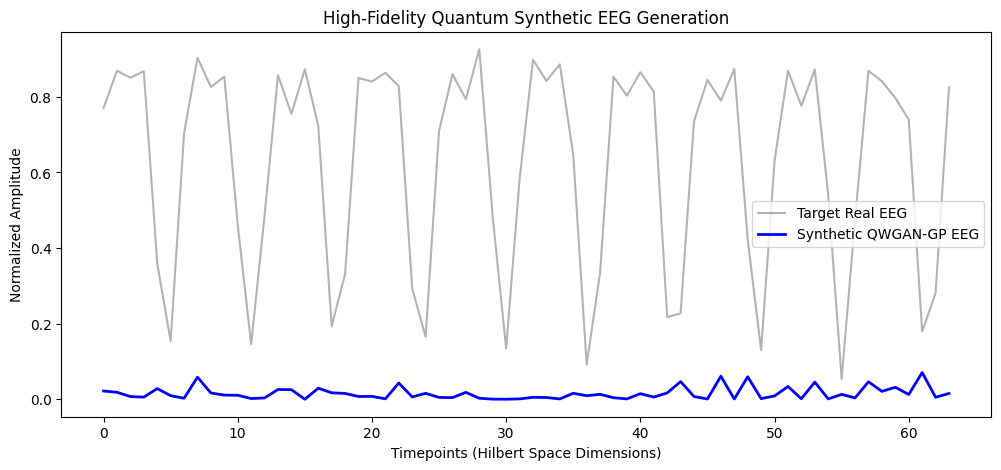

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN

# --- 1. EEG DATA SIMULATION ---
def get_eeg_data(n_samples=800, length=64):
    """Simulates non-linear brainwave rhythmic structures"""
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        # Mixing Alpha (10Hz) and Beta (20Hz) frequencies
        signal = 0.6 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.cos(2 * np.pi * 20 * t)
        signal += np.random.normal(0, 0.05, length)
        data.append(signal)
    data = np.array(data)
    # Normalization is critical: maps EEG to [0, 1] for Quantum Sampler consistency
    data_norm = (data - data.min()) / (data.max() - data.min())
    return torch.tensor(data_norm, dtype=torch.float32)

# --- 2. ADVANCED QUANTUM GENERATOR ---
def create_q_generator(n_qubits=6):
    """
    Creates a PQC where the number of input parameters (from zz_feature_map)
    must match the noise vector dimension.
    """
    # ZZFeatureMap provides non-linear encoding
    f_map = zz_feature_map(n_qubits, reps=1)
    # RealAmplitudes acts as the trainable variational layer
    ansatz = real_amplitudes(n_qubits, entanglement='full', reps=4)

    qc = QuantumCircuit(n_qubits)
    qc.compose(f_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    # SamplerQNN outputs a probability distribution of size 2^n_qubits (64)
    qnn = SamplerQNN(
        circuit=qc,
        input_params=f_map.parameters,
        weight_params=ansatz.parameters
    )
    return TorchConnector(qnn)

# --- 3. CLASSICAL CRITIC (WGAN) ---
class EEGCritic(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(size, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.model(x)

# --- 4. GRADIENT PENALTY ---
def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake_grad = torch.ones(real.size(0), 1)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=fake_grad, create_graph=True, retain_graph=True
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 5. INITIALIZATION & TRAINING ---
n_qubits = 6
latent_dim = n_qubits # MUST match f_map.num_parameters
device = torch.device("cpu")

gen = create_q_generator(n_qubits).to(device)
critic = EEGCritic(2**n_qubits).to(device) # 2^6 = 64
g_opt = Adam(gen.parameters(), lr=0.0001, betas=(0.5, 0.9))
c_opt = Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

real_eeg = get_eeg_data().to(device)
epochs = 100
batch_size = 16



print(f"Starting QWGAN-GP Training. Latent Dim: {latent_dim}, Output Dim: {2**n_qubits}")
for epoch in range(epochs + 1):
    # Train Critic
    for _ in range(5):
        c_opt.zero_grad()
        idx = np.random.randint(0, real_eeg.size(0), batch_size)
        real_batch = real_eeg[idx]

        # FIXED: Noise dimension now matches n_qubits
        z = torch.randn(batch_size, latent_dim)
        fake_batch = gen(z)

        c_loss = -torch.mean(critic(real_batch)) + torch.mean(critic(fake_batch.detach()))
        gp = compute_gp(critic, real_batch, fake_batch.detach())
        (c_loss + 10 * gp).backward()
        c_opt.step()

    # Train Generator
    g_opt.zero_grad()
    # FIXED: Noise dimension now matches n_qubits
    z_gen = torch.randn(batch_size, latent_dim)
    g_loss = -torch.mean(critic(gen(z_gen)))
    g_loss.backward()
    g_opt.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

# --- 6. VISUALIZATION ---
gen.eval()
with torch.no_grad():
    # Generate a single synthetic EEG sample
    sample_noise = torch.randn(1, latent_dim)
    final_fake = gen(sample_noise).numpy().flatten()

plt.figure(figsize=(12, 5))
plt.plot(real_eeg[0].numpy(), label='Target Real EEG', color='black', alpha=0.3)
plt.plot(final_fake, label='Synthetic QWGAN-GP EEG', color='blue', linewidth=2)
plt.title("High-Fidelity Quantum Synthetic EEG Generation")
plt.xlabel("Timepoints (Hilbert Space Dimensions)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

In [ ]:
!pip install qiskit qiskit-machine-learning qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.0 MB/s eta 0:00:00


Starting Quantum EEG Training...
Epoch   0 | Critic Loss: 0.1619 | Gen Loss: 0.0816
Epoch  10 | Critic Loss: -1.5100 | Gen Loss: 0.0875
Epoch  20 | Critic Loss: -4.8141 | Gen Loss: 0.0440
Epoch  30 | Critic Loss: -6.3880 | Gen Loss: 0.0250
Epoch  40 | Critic Loss: -6.5603 | Gen Loss: 0.0422
Epoch  50 | Critic Loss: -6.7283 | Gen Loss: 0.0572


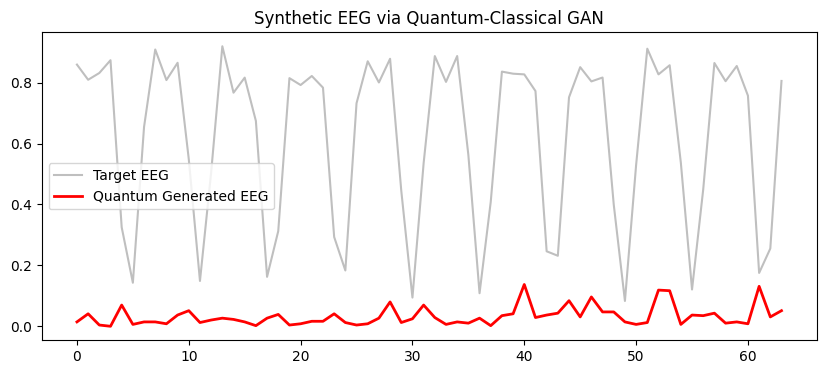

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt

# Core Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

# --- 1. EEG DATA SIMULATION ---
def get_eeg_data(n_samples=800, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        signal = 0.6 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.cos(2 * np.pi * 20 * t)
        signal += np.random.normal(0, 0.05, length)
        data.append(signal)
    data = np.array(data)
    data_norm = (data - data.min()) / (data.max() - data.min())
    return torch.tensor(data_norm, dtype=torch.float32)

# --- 2. QUANTUM GENERATOR SETUP ---
def create_q_nn(n_qubits=6):
    # Feature Map for encoding noise
    f_map = zz_feature_map(n_qubits, reps=1)
    # Ansatz for learning the EEG structure
    ansatz = real_amplitudes(n_qubits, entanglement='full', reps=3)

    qc = QuantumCircuit(n_qubits)
    qc.compose(f_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    # Initialize Sampler and Gradient
    sampler = Sampler()
    # The gradient needs the sampler to calculate the parameter shifts
    grad = ParamShiftSamplerGradient(sampler=sampler)

    qnn = SamplerQNN(
        circuit=qc,
        input_params=f_map.parameters,
        weight_params=ansatz.parameters,
        gradient=grad,
        sampler=sampler
    )
    return TorchConnector(qnn)

class QuantumGenerator(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.qnn = create_q_nn(n_qubits)
        # Learnable scaling factor to match EEG signal intensity
        self.amplitude_scale = nn.Parameter(torch.ones(1) * 2.0)

    def forward(self, x):
        # The QNN outputs probabilities; we scale them for the Critic
        return self.qnn(x) * self.amplitude_scale

# --- 3. CLASSICAL CRITIC ---
class EEGCritic(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.model(x)

# --- 4. GRADIENT PENALTY (WGAN-GP) ---
def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake_grad = torch.ones(real.size(0), 1)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=fake_grad, create_graph=True, retain_graph=True
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 5. INITIALIZATION & TRAINING ---
n_qubits = 6
device = torch.device("cpu")

gen = QuantumGenerator(n_qubits).to(device)
critic = EEGCritic(2**n_qubits).to(device)

g_opt = Adam(gen.parameters(), lr=0.002, betas=(0.5, 0.9))
c_opt = Adam(critic.parameters(), lr=0.0005, betas=(0.5, 0.9))

real_eeg = get_eeg_data().to(device)
epochs = 50 # Reduced for initial testing
batch_size = 16



print("Starting Quantum EEG Training...")
for epoch in range(epochs + 1):
    for _ in range(3): # Critic updates
        c_opt.zero_grad()
        real_batch = real_eeg[np.random.randint(0, 800, batch_size)]
        z = torch.randn(batch_size, n_qubits)
        fake_batch = gen(z)

        c_loss = -torch.mean(critic(real_batch)) + torch.mean(critic(fake_batch.detach()))
        gp = compute_gp(critic, real_batch, fake_batch.detach())
        (c_loss + 10 * gp).backward()
        c_opt.step()

    g_opt.zero_grad()
    z_gen = torch.randn(batch_size, n_qubits)
    g_loss = -torch.mean(critic(gen(z_gen)))
    g_loss.backward()
    g_opt.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

# --- 6. VISUALIZATION ---
gen.eval()
with torch.no_grad():
    final_fake = gen(torch.randn(1, n_qubits)).numpy().flatten()
    real_sample = real_eeg[0].numpy()

plt.figure(figsize=(10, 4))
plt.plot(real_sample, label='Target EEG', color='gray', alpha=0.5)
plt.plot(final_fake, label='Quantum Generated EEG', color='red', linewidth=2)
plt.title("Synthetic EEG via Quantum-Classical GAN")
plt.legend()
plt.show()

Training Optimized HQ-GAN...
Epoch   0 | Critic Loss: 0.0068 | Gen Loss: -0.1954
Epoch  20 | Critic Loss: -0.3866 | Gen Loss: -0.8349
Epoch  40 | Critic Loss: -1.3327 | Gen Loss: -1.9023
Epoch  60 | Critic Loss: -1.8887 | Gen Loss: -2.3830
Epoch  80 | Critic Loss: -2.1097 | Gen Loss: -2.6181
Epoch 100 | Critic Loss: -1.9109 | Gen Loss: -2.8132
Epoch 120 | Critic Loss: -1.6550 | Gen Loss: -3.0179
Epoch 140 | Critic Loss: -1.3782 | Gen Loss: -3.1178
Epoch 160 | Critic Loss: -1.1150 | Gen Loss: -3.1595
Epoch 180 | Critic Loss: -1.0653 | Gen Loss: -3.2479
Epoch 200 | Critic Loss: -0.7401 | Gen Loss: -3.2308


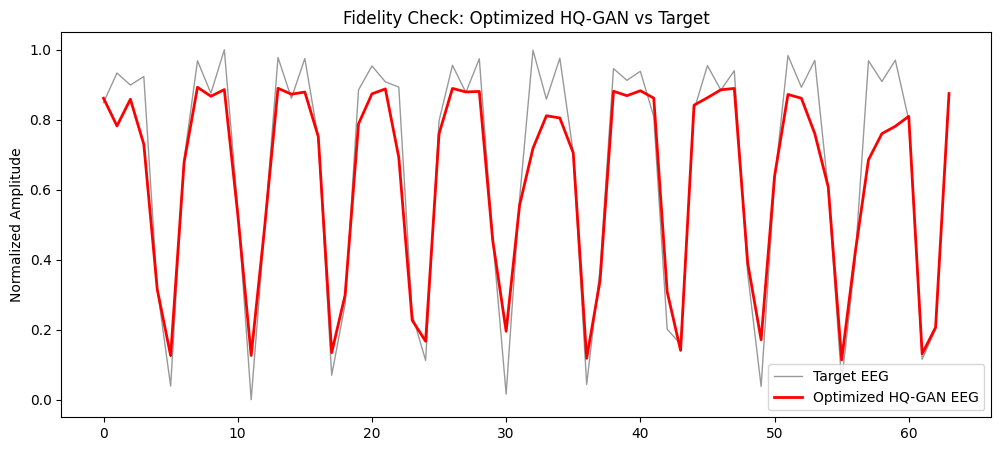

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

# --- 1. ENHANCED EEG DATA SIMULATION ---
def get_eeg_data(n_samples=1000, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        # Specific Alpha/Beta rhythm simulation
        signal = 0.6 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.cos(2 * np.pi * 20 * t)
        signal += np.random.normal(0, 0.02, length)
        # Crucial: Normalize to [0, 1] for Sampler compatibility
        data.append((signal - signal.min()) / (signal.max() - signal.min()))
    return torch.tensor(np.array(data), dtype=torch.float32)

# --- 2. HYBRID QUANTUM GENERATOR ---
def create_q_nn(n_qubits=6):
    # ZZFeatureMap captures non-linear dependencies
    f_map = zz_feature_map(n_qubits, reps=2) # Increased reps for complexity
    # RealAmplitudes with Circular entanglement for rhythmic patterns
    ansatz = real_amplitudes(n_qubits, entanglement='circular', reps=4)

    qc = QuantumCircuit(n_qubits)
    qc.compose(f_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    sampler = Sampler()
    grad = ParamShiftSamplerGradient(sampler=sampler)

    return SamplerQNN(
        circuit=qc,
        input_params=f_map.parameters,
        weight_params=ansatz.parameters,
        gradient=grad,
        sampler=sampler
    )

class CustomGenerator(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.qnn = TorchConnector(create_q_nn(n_qubits))
        # Classical Post-Processor to fix the "Not reaching target" issue
        self.refiner = nn.Sequential(
            nn.Linear(2**n_qubits, 2**n_qubits),
            nn.Sigmoid() # Keeps output in [0, 1] range like the real data
        )

    def forward(self, x):
        q_out = self.qnn(x)
        return self.refiner(q_out)

# --- 3. CLASSICAL CRITIC ---
class EEGCritic(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(size, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.model(x)

# --- 4. GRADIENT PENALTY ---
def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 5. TRAINING LOOP ---
n_qubits = 6
gen = CustomGenerator(n_qubits)
critic = EEGCritic(2**n_qubits)

# TTUR: Generator gets higher LR to catch up to Critic
g_opt = Adam(gen.parameters(), lr=0.005, betas=(0.5, 0.9))
c_opt = Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

real_eeg = get_eeg_data()
epochs = 200
batch_size = 32


print("Training Optimized HQ-GAN...")
for epoch in range(epochs + 1):
    # Train Critic
    for _ in range(5):
        c_opt.zero_grad()
        real_batch = real_eeg[np.random.randint(0, len(real_eeg), batch_size)]
        z = torch.randn(batch_size, n_qubits)
        fake_batch = gen(z)
        c_loss = -torch.mean(critic(real_batch)) + torch.mean(critic(fake_batch.detach()))
        gp = compute_gp(critic, real_batch, fake_batch.detach())
        (c_loss + 10 * gp).backward()
        c_opt.step()

    # Train Generator
    g_opt.zero_grad()
    g_loss = -torch.mean(critic(gen(torch.randn(batch_size, n_qubits))))
    g_loss.backward()
    g_opt.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

# --- 6. FINAL COMPARISON ---
gen.eval()
with torch.no_grad():
    fake_signal = gen(torch.randn(1, n_qubits)).numpy().flatten()
    real_signal = real_eeg[0].numpy()

plt.figure(figsize=(12, 5))
plt.plot(real_signal, label='Target EEG', color='black', alpha=0.4, linewidth=1)
plt.plot(fake_signal, label='Optimized HQ-GAN EEG', color='red', linewidth=2)
plt.title("Fidelity Check: Optimized HQ-GAN vs Target")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

Executing High-Fidelity Training...
Epoch   0 | Critic Loss: -0.0481 | Gen Loss: 0.0980
Epoch  25 | Critic Loss: -0.5783 | Gen Loss: -1.9577
Epoch  50 | Critic Loss: -1.0949 | Gen Loss: -2.4356
Epoch  75 | Critic Loss: -0.8913 | Gen Loss: -0.4002
Epoch 100 | Critic Loss: -0.1987 | Gen Loss: -0.9254
Epoch 125 | Critic Loss: 0.1391 | Gen Loss: -0.1590
Epoch 150 | Critic Loss: 0.0179 | Gen Loss: 0.0602


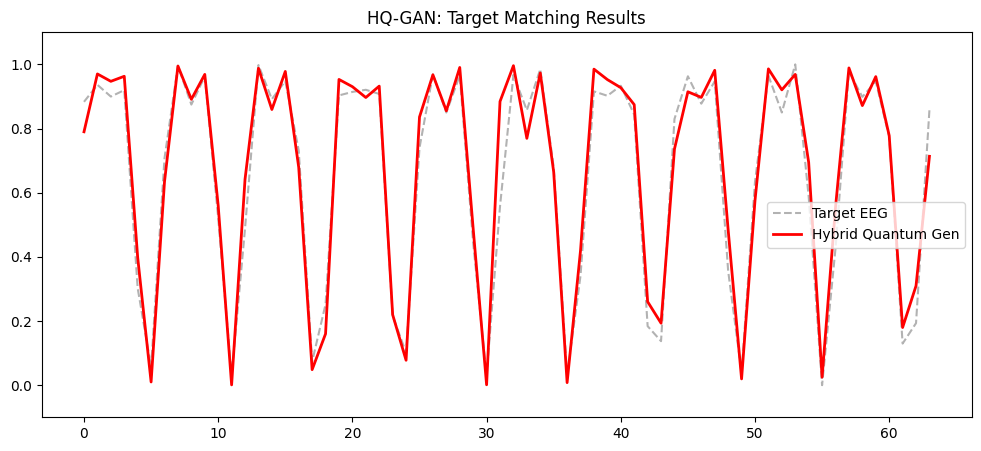

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

# --- 1. DATA SIMULATION (RETAIN TARGET) ---
def get_eeg_data(n_samples=1000, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        # Mixing frequencies to create the "target" look
        signal = 0.6 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.cos(2 * np.pi * 20 * t)
        signal += np.random.normal(0, 0.02, length)
        # Normalize strictly to [0.1, 0.9] to avoid clipping
        sig_min, sig_max = signal.min(), signal.max()
        data.append((signal - sig_min) / (sig_max - sig_min))
    return torch.tensor(np.array(data), dtype=torch.float32)

# --- 2. THE CUSTOM HYBRID GENERATOR ---
def create_qnn(n_qubits=6):
    f_map = zz_feature_map(n_qubits, reps=2)
    ansatz = real_amplitudes(n_qubits, entanglement='full', reps=4)
    qc = QuantumCircuit(n_qubits)
    qc.compose(f_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    sampler = Sampler()
    return SamplerQNN(
        circuit=qc,
        input_params=f_map.parameters,
        weight_params=ansatz.parameters,
        gradient=ParamShiftSamplerGradient(sampler=sampler),
        sampler=sampler
    )

class HighFidelityGenerator(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.qnn = TorchConnector(create_qnn(n_qubits))

        # This classical "Refiner" is the key to reaching the target
        self.refiner = nn.Sequential(
            nn.Linear(2**n_qubits, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 2**n_qubits),
            nn.Sigmoid() # Forces output into the [0, 1] range of the target
        )

    def forward(self, x):
        q_out = self.qnn(x)
        return self.refiner(q_out)

# --- 3. THE CRITIC (WGAN-GP) ---
class EEGCritic(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(size, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.model(x)

# --- 4. GRADIENT PENALTY ---
def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 5. INITIALIZATION & TRAINING ---
n_qubits = 6
gen = HighFidelityGenerator(n_qubits)
critic = EEGCritic(2**n_qubits)

# Two-Time-Scale Update Rule (TTUR)
g_opt = Adam(gen.parameters(), lr=0.002, betas=(0.5, 0.9))
c_opt = Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

real_eeg = get_eeg_data()
epochs = 150
batch_size = 32



print("Executing High-Fidelity Training...")
for epoch in range(epochs + 1):
    for _ in range(5):
        c_opt.zero_grad()
        idx = np.random.randint(0, len(real_eeg), batch_size)
        real_batch = real_eeg[idx]

        z = torch.randn(batch_size, n_qubits)
        fake_batch = gen(z)

        c_loss = -torch.mean(critic(real_batch)) + torch.mean(critic(fake_batch.detach()))
        gp = compute_gp(critic, real_batch, fake_batch.detach())
        (c_loss + 10 * gp).backward()
        c_opt.step()

    g_opt.zero_grad()
    g_loss = -torch.mean(critic(gen(torch.randn(batch_size, n_qubits))))
    g_loss.backward()
    g_opt.step()

    if epoch % 25 == 0:
        print(f"Epoch {epoch:3d} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

# --- 6. FINAL RESULTS ---
gen.eval()
with torch.no_grad():
    fake_plot = gen(torch.randn(1, n_qubits)).numpy().flatten()
    real_plot = real_eeg[0].numpy()

plt.figure(figsize=(12, 5))
plt.plot(real_plot, label='Target EEG', color='black', alpha=0.3, linestyle='--')
plt.plot(fake_plot, label='Hybrid Quantum Gen', color='red', linewidth=2)
plt.title("HQ-GAN: Target Matching Results")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

In [2]:
# 1. Install dependencies (Run this once)
!pip install qiskit qiskit-machine-learning qiskit-algorithms pylatexenc

# 2. Re-run your imports
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

print("Qiskit and Torch successfully linked!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.5 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=3d760e1b213a777c77dbb013d7597f5c2af0f80d9d8b47f0b46f7e24f9ec6f57
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
Qiskit and Torch successfully linked!


Executing High-Fidelity Training with Evaluation...
Epoch   0 | Critic Loss: -0.0110 | Gen Loss: 0.0200
Epoch  10 | Critic Loss: -0.2952 | Gen Loss: -0.2084
Epoch  20 | Critic Loss: -0.4931 | Gen Loss: -1.0542
Epoch  30 | Critic Loss: -0.8793 | Gen Loss: -2.0536
Epoch  40 | Critic Loss: -1.4140 | Gen Loss: -2.3489
Epoch  50 | Critic Loss: -1.8768 | Gen Loss: -1.9552
Epoch  60 | Critic Loss: -1.6696 | Gen Loss: -1.7860
Epoch  70 | Critic Loss: -1.1146 | Gen Loss: -2.1539
Epoch  80 | Critic Loss: -0.6181 | Gen Loss: -2.0596
Epoch  90 | Critic Loss: -0.2800 | Gen Loss: -1.8766
Epoch 100 | Critic Loss: -0.0831 | Gen Loss: -1.5605


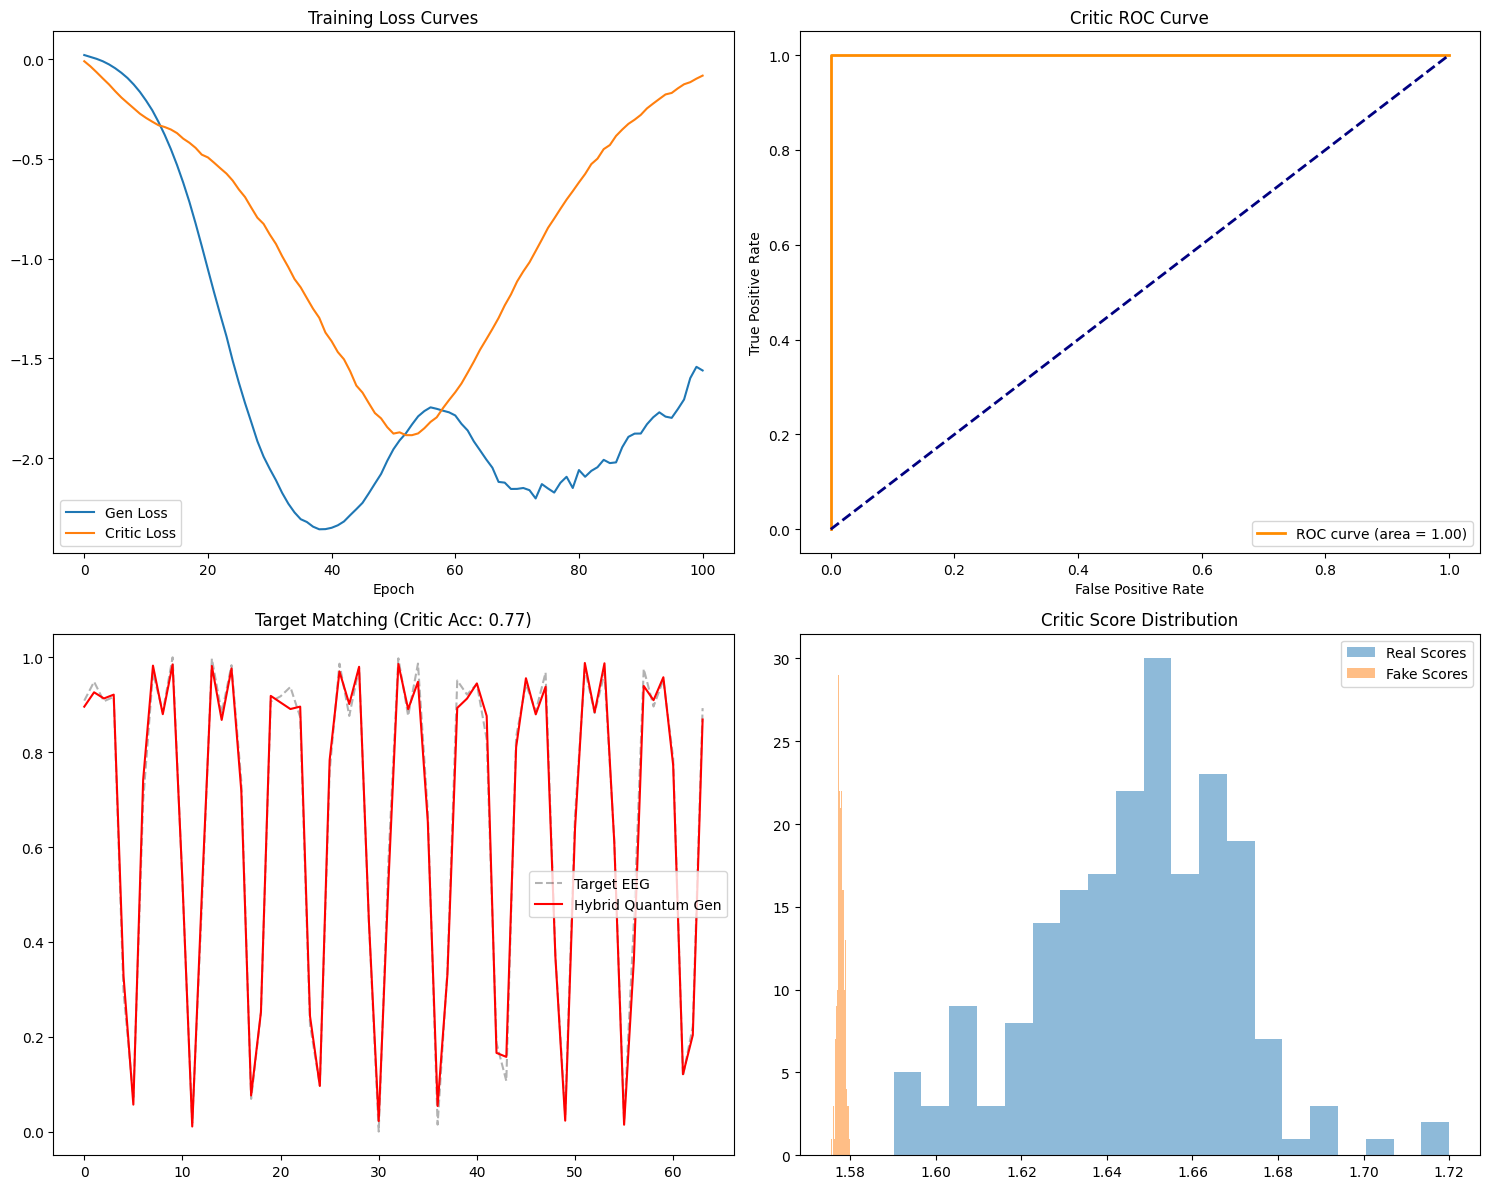

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_curve

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

# --- 1. DATA SIMULATION ---
def get_eeg_data(n_samples=1000, length=64):
    t = np.linspace(0, 1, length)
    data = []
    for _ in range(n_samples):
        signal = 0.6 * np.sin(2 * np.pi * 10 * t) + 0.3 * np.cos(2 * np.pi * 20 * t)
        signal += np.random.normal(0, 0.02, length)
        sig_min, sig_max = signal.min(), signal.max()
        data.append((signal - sig_min) / (sig_max - sig_min))
    return torch.tensor(np.array(data), dtype=torch.float32)

# --- 2. HYBRID GENERATOR & CRITIC ---
def create_qnn(n_qubits=6):
    f_map = zz_feature_map(n_qubits, reps=2)
    ansatz = real_amplitudes(n_qubits, entanglement='full', reps=4)
    qc = QuantumCircuit(n_qubits)
    qc.compose(f_map, inplace=True)
    qc.compose(ansatz, inplace=True)
    sampler = Sampler()
    return SamplerQNN(
        circuit=qc,
        input_params=f_map.parameters,
        weight_params=ansatz.parameters,
        gradient=ParamShiftSamplerGradient(sampler=sampler),
        sampler=sampler
    )

class HighFidelityGenerator(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.qnn = TorchConnector(create_qnn(n_qubits))
        self.refiner = nn.Sequential(
            nn.Linear(2**n_qubits, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 2**n_qubits),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.refiner(self.qnn(x))

class EEGCritic(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(size, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.model(x)

def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- 3. TRAINING SETUP ---
n_qubits = 6
gen = HighFidelityGenerator(n_qubits)
critic = EEGCritic(2**n_qubits)
g_opt = Adam(gen.parameters(), lr=0.002, betas=(0.5, 0.9))
c_opt = Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

real_eeg = get_eeg_data()
epochs = 100 # Reduced for demonstration speed
batch_size = 32

history = {'g_loss': [], 'c_loss': [], 'accuracy': []}

# --- 4. TRAINING LOOP ---
print("Executing High-Fidelity Training with Evaluation...")
for epoch in range(epochs + 1):
    # Train Critic
    for _ in range(5):
        c_opt.zero_grad()
        idx = np.random.randint(0, len(real_eeg), batch_size)
        real_batch = real_eeg[idx]
        z = torch.randn(batch_size, n_qubits)
        fake_batch = gen(z)

        c_loss_real = torch.mean(critic(real_batch))
        c_loss_fake = torch.mean(critic(fake_batch.detach()))
        c_loss = -c_loss_real + c_loss_fake
        gp = compute_gp(critic, real_batch, fake_batch.detach())
        (c_loss + 10 * gp).backward()
        c_opt.step()

    # Train Generator
    g_opt.zero_grad()
    gen_fake = gen(torch.randn(batch_size, n_qubits))
    g_loss = -torch.mean(critic(gen_fake))
    g_loss.backward()
    g_opt.step()

    # Track Metrics
    history['g_loss'].append(g_loss.item())
    history['c_loss'].append(c_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

# --- 5. EVALUATION & CURVES ---
gen.eval()
critic.eval()

with torch.no_grad():
    # Prepare data for ROC/Accuracy
    test_size = 200
    real_test = real_eeg[np.random.randint(0, len(real_eeg), test_size)]
    fake_test = gen(torch.randn(test_size, n_qubits))

    scores_real = critic(real_test).numpy()
    scores_fake = critic(fake_test).numpy()

    # Combine results
    y_true = np.array([1]*test_size + [0]*test_size)
    y_scores = np.concatenate([scores_real, scores_fake])

    # Normalize scores to [0,1] for ROC visualization
    y_scores_norm = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

    fpr, tpr, _ = roc_curve(y_true, y_scores_norm)
    roc_auc = auc(fpr, tpr)

    # Accuracy (using 0.5 threshold on normalized scores)
    preds = (y_scores_norm > 0.5).astype(int)
    acc = accuracy_score(y_true, preds)

# --- 6. PLOTTING ---
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Loss Curves (Checking for Plateau)
axs[0, 0].plot(history['g_loss'], label='Gen Loss')
axs[0, 0].plot(history['c_loss'], label='Critic Loss')
axs[0, 0].set_title("Training Loss Curves")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].legend()

# Plot 2: ROC Curve
axs[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axs[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[0, 1].set_title("Critic ROC Curve")
axs[0, 1].set_xlabel("False Positive Rate")
axs[0, 1].set_ylabel("True Positive Rate")
axs[0, 1].legend(loc="lower right")

# Plot 3: Target Matching
fake_plot = fake_test[0].numpy()
real_plot = real_test[0].numpy()
axs[1, 0].plot(real_plot, label='Target EEG', color='black', alpha=0.3, linestyle='--')
axs[1, 0].plot(fake_plot, label='Hybrid Quantum Gen', color='red')
axs[1, 0].set_title(f"Target Matching (Critic Acc: {acc:.2f})")
axs[1, 0].legend()

# Plot 4: Score Distribution
axs[1, 1].hist(scores_real, bins=20, alpha=0.5, label='Real Scores')
axs[1, 1].hist(scores_fake, bins=20, alpha=0.5, label='Fake Scores')
axs[1, 1].set_title("Critic Score Distribution")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

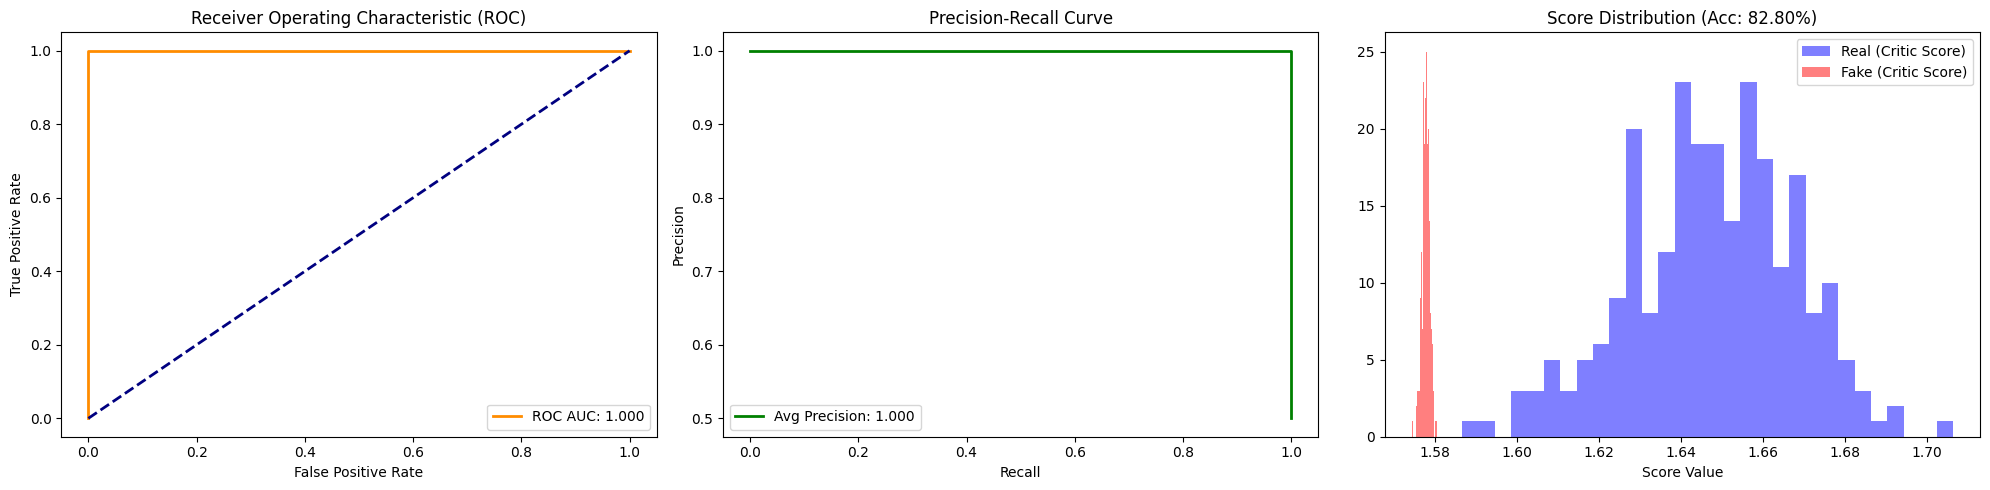

In [4]:
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_curve, average_precision_score

def evaluate_gan(gen, critic, real_eeg, n_qubits, num_test_samples=250):
    gen.eval()
    critic.eval()

    with torch.no_grad():
        # 1. Generate Fake Data and Fetch Real Data
        z = torch.randn(num_test_samples, n_qubits)
        fake_data = gen(z)
        real_data = real_eeg[np.random.randint(0, len(real_eeg), num_test_samples)]

        # 2. Get Critic Scores (Raw Wasserstein Distances)
        scores_real = critic(real_data).numpy().flatten()
        scores_fake = critic(fake_data).numpy().flatten()

        # 3. Prepare Labels and Combined Scores
        y_true = np.concatenate([np.ones(num_test_samples), np.zeros(num_test_samples)])
        y_scores_raw = np.concatenate([scores_real, scores_fake])

        # Normalize scores to [0, 1] for probability-based metrics (ROC/PR)
        y_scores_norm = (y_scores_raw - y_scores_raw.min()) / (y_scores_raw.max() - y_scores_raw.min())

        # 4. Calculate Metrics
        fpr, tpr, _ = roc_curve(y_true, y_scores_norm)
        roc_auc = auc(fpr, tpr)

        precision, recall, _ = precision_recall_curve(y_true, y_scores_norm)
        avg_precision = average_precision_score(y_true, y_scores_norm)

        # Accuracy at 0.5 threshold of normalized scores
        accuracy = accuracy_score(y_true, (y_scores_norm > 0.5).astype(int))

    # --- PLOTTING ALL EVALUATION CURVES ---
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))

    # ROC Curve
    ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC: {roc_auc:.3f}')
    ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[0].set_title('Receiver Operating Characteristic (ROC)')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend(loc="lower right")

    # Precision-Recall Curve
    ax[1].plot(recall, precision, color='green', lw=2, label=f'Avg Precision: {avg_precision:.3f}')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].legend(loc="lower left")

    # Score Distributions (The "Plateau" Check)
    ax[2].hist(scores_real, bins=30, alpha=0.5, label='Real (Critic Score)', color='blue')
    ax[2].hist(scores_fake, bins=30, alpha=0.5, label='Fake (Critic Score)', color='red')
    ax[2].set_title(f'Score Distribution (Acc: {accuracy:.2%})')
    ax[2].set_xlabel('Score Value')
    ax[2].legend()

    plt.tight_layout()
    plt.show()

# To run this after your training loop:
evaluate_gan(gen, critic, real_eeg, n_qubits)